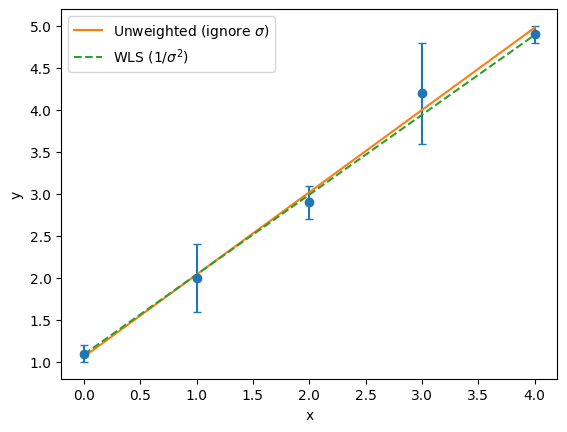

OLS: a = 0.98 b = 1.0599999999999994
WLS: a = 0.9512058688674917 b = 1.0885557083906467


In [12]:
# PHY 657 PS3 - Problem 2 

import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("weighted_regression_dataset.csv", delimiter=",", skiprows=1)

# sanity check
assert len(x) == len(y) == len(sigma)

# (a) OLS (ignore sigma)
a_ols, b_ols = np.polyfit(x, y, 1)

# (b) WLS (polyfit expects weights ~ 1/sigma)
a_wls, b_wls = np.polyfit(x, y, 1, w=1.0/sigma)

# plot
xx = np.linspace(x.min(), x.max(), 200)
plt.errorbar(x, y, yerr=sigma, fmt='o', capsize=3)
plt.plot(xx, a_ols*xx + b_ols, label='Unweighted (ignore $\\sigma$)')
plt.plot(xx, a_wls*xx + b_wls, '--', label='WLS ($1/\\sigma^2$)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

print("OLS: a =", a_ols, "b =", b_ols)
print("WLS: a =", a_wls, "b =", b_wls)

## (c) Comparison

### 1. Which points influenced the weighted fit more strongly?

Points with smaller uncertainties $ \sigma_i $ influence the fit more strongly because the weights are

$
w_i = \frac{1}{\sigma_i^2}.
$

A smaller $ \sigma_i $ means a larger weight. For example, if $ \sigma_i $ is reduced by a factor of 2, then the weight increases by a factor of 4. As a result, precise measurements pull the fitted line more strongly than noisy measurements.

---

### 2. Why does inverse-variance weighting improve parameter estimation?

Assume measurement errors are Gaussian with known variances:

$
y_i = a x_i + b + \varepsilon_i,
\qquad
\varepsilon_i \sim \mathcal{N}(0, \sigma_i^2).
$

Minimizing

$
\chi^2 = \sum_i \frac{(y_i - a x_i - b)^2}{\sigma_i^2}
$

is equivalent to maximizing the likelihood. Therefore, weighted least squares (WLS) is the maximum-likelihood estimator under heteroskedastic Gaussian noise.

It improves estimation because:

- Measurements with large variance contribute less.
- Measurements with small variance contribute more.
- The estimator uses the statistical information optimally.

Intuitively: **trust precise points more and noisy points less.**

---

## (d) Conceptual Connection to $ \Sigma^{-1} $

If errors are correlated with covariance matrix $ \Sigma $, the generalized chi-square becomes

$
\chi^2(\theta)
=
(d - m(\theta))^{\mathsf T}
\Sigma^{-1}
(d - m(\theta)),
$

where $ d $ is the data vector and $ m(\theta) $ is the model prediction.

The matrix $ \Sigma^{-1} $ appears because it whitens the noise.  
Multiplying by $ \Sigma^{-1/2} $ transforms correlated, unequal-variance noise into uncorrelated, unit-variance noise.

After whitening, ordinary least squares becomes optimal.  
Transforming back to the original space naturally introduces the $ \Sigma^{-1} $ weighting.